<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/01-machine-learning/classificacao-acoes-petr4-knn/classificacao-petr4-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instala a biblioteca do Yahoo Finance
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
from google.colab import files

# 1. Escolher o código de ativo da B3
codigo_ativo = "PETR4.SA"

# 2. Definir o período de 3 anos (2023, 2024 e 2025)
data_inicio = "2023-01-01"
data_fim = "2025-12-31"

print(f"Iniciando o download do histórico diário de {codigo_ativo}...")

# 3. Baixar os dados de cotação
dados = yf.download(codigo_ativo, start=data_inicio, end=data_fim, interval="1d")

if dados.empty:
    print("Nenhum dado encontrado. Verifique se o código do ativo está correto e possui o sufixo '.SA'.")
else:
    print("\nDownload processado com sucesso!")

    # Gerando o arquivo CSV
    nome_arquivo = f"cotacoes_{codigo_ativo.replace('.SA', '')}_2023_2025.csv"
    dados.to_csv(nome_arquivo)

    # Forçando o navegador a fazer o download do arquivo para a sua máquina
    print(f"\nIniciando o download do arquivo '{nome_arquivo}' para o seu computador...")
    files.download(nome_arquivo)

Iniciando o download do histórico diário de PETR4.SA...


/tmp/ipykernel_1324/2910605921.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(codigo_ativo, start=data_inicio, end=data_fim, interval="1d")
[*********************100%***********************]  1 of 1 completed


Download processado com sucesso!

Iniciando o download do arquivo 'cotacoes_PETR4_2023_2025.csv' para o seu computador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# O yfinance retorna as colunas em inglês.
# Abertura = 'Open' | Fechamento = 'Close'

# Calculando a diferença (Fechamento - Abertura para refletir se a ação subiu no dia)
dados['Diferenca'] = dados['Close'] - dados['Open']

# Criando o atributo alvo: 1 se a diferença for positiva, 0 caso contrário
dados['Alvo'] = dados['Diferenca'].apply(lambda x: 1 if x > 0 else 0)

print("Etapa 2 concluída: Atributo alvo calculado com sucesso!\n")

# Exibindo as primeiras 10 linhas apenas com as colunas relevantes para conferência
print(dados[['Open', 'Close', 'Diferenca', 'Alvo']].head(10))

Etapa 2 concluída: Atributo alvo calculado com sucesso!

Price            Open      Close Diferenca Alvo
Ticker       PETR4.SA   PETR4.SA               
Date                                           
2023-01-02  12.919328  12.579057 -0.340272    0
2023-01-03  12.590036  12.260741 -0.329295    0
2023-01-04  12.052184  12.650403  0.598219    1
2023-01-05  12.809561  13.105926  0.296365    1
2023-01-06  13.138856  13.029091 -0.109765    0
2023-01-09  12.897375  13.100440  0.203066    1
2023-01-10  13.144344  13.221179  0.076835    1
2023-01-11  13.254111  13.325459  0.071348    1
2023-01-12  13.330947  13.517547  0.186599    1
2023-01-13  13.413270  13.484616  0.071347    1


In [ ]:
# Separando os dados de Treinamento (anos de 2023 e 2024)
dados_treinamento = dados.loc['2023-01-01':'2024-12-31']

# Separando os dados de Teste (ano de 2025)
dados_teste = dados.loc['2025-01-01':'2025-12-31']

print("Etapa 3 concluída: Dados separados com sucesso!\n")

# Exibindo a quantidade de registos em cada base para confirmar a separação
print(f"Quantidade de dias para Treinamento (2023-2024): {len(dados_treinamento)} registos")
print(f"Quantidade de dias para Teste (2025): {len(dados_teste)} registos")

Etapa 3 concluída: Dados separados com sucesso!

Quantidade de dias para Treinamento (2023-2024): 499 registos
Quantidade de dias para Teste (2025): 250 registos


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Definindo as variáveis previsoras (features)
features = ['Open', 'High', 'Low', 'Volume']

# Separando features (X) e o alvo (y) para o Treinamento
X_treino = dados_treinamento[features]
y_treino = dados_treinamento['Alvo']

# Separando features (X) e o alvo (y) para o Teste
X_teste = dados_teste[features]
y_teste = dados_teste['Alvo']

# Etapa 4: Escolher e implementar o algoritmo (KNN)
# Etapa 5: Ajustar os parâmetros (começaremos com n_neighbors=5)
modelo_knn = KNeighborsClassifier(n_neighbors=5)

print("Iniciando o treinamento do algoritmo KNN com os dados de 2023-2024...")
modelo_knn.fit(X_treino, y_treino)

print("Treinamento concluído! Realizando simulações nos dados de Teste (2025)...")
previsoes = modelo_knn.predict(X_teste)

# Calculando a acurácia inicial apenas para termos uma ideia do desempenho bruto
acuracia_inicial = accuracy_score(y_teste, previsoes)
print(f"\nEtapas 4 e 5 concluídas com sucesso!")
print(f"Acurácia inicial do modelo: {acuracia_inicial * 100:.2f}%")

Iniciando o treinamento do algoritmo KNN com os dados de 2023-2024...
Treinamento concluído! Realizando simulações nos dados de Teste (2025)...

Etapas 4 e 5 concluídas com sucesso!
Acurácia inicial do modelo: 49.20%


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Retirando atributos irrelevantes/ruídos: focaremos apenas nos preços e descartaremos o 'Volume'
features_revisadas = ['Open', 'High', 'Low']

X_treino_revisado = dados_treinamento[features_revisadas]
X_teste_revisado = dados_teste[features_revisadas]

# 2. Normalizando os dados (colocando todos na mesma escala padronizada)
scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino_revisado)
X_teste_norm = scaler.transform(X_teste_revisado)

# 3. Nova forma de treinar: Ajustando o hiperparâmetro do KNN para 11 vizinhos
modelo_knn_melhorado = KNeighborsClassifier(n_neighbors=11)

print("Treinando o novo modelo com dados normalizados e sem ruídos...")
modelo_knn_melhorado.fit(X_treino_norm, y_treino)

print("Realizando novas simulações no ano de 2025...")
novas_previsoes = modelo_knn_melhorado.predict(X_teste_norm)

# Calculando a nova acurácia
nova_acuracia = accuracy_score(y_teste, novas_previsoes)

print(f"\nEtapa 6 concluída com sucesso!")
print(f"Acurácia anterior (Dados Brutos): {acuracia_inicial * 100:.2f}%")
print(f"Nova acurácia (Dados Normalizados + Ajuste): {nova_acuracia * 100:.2f}%")

Treinando o novo modelo com dados normalizados e sem ruídos...
Realizando novas simulações no ano de 2025...

Etapa 6 concluída com sucesso!
Acurácia anterior (Dados Brutos): 49.20%
Nova acurácia (Dados Normalizados + Ajuste): 66.40%


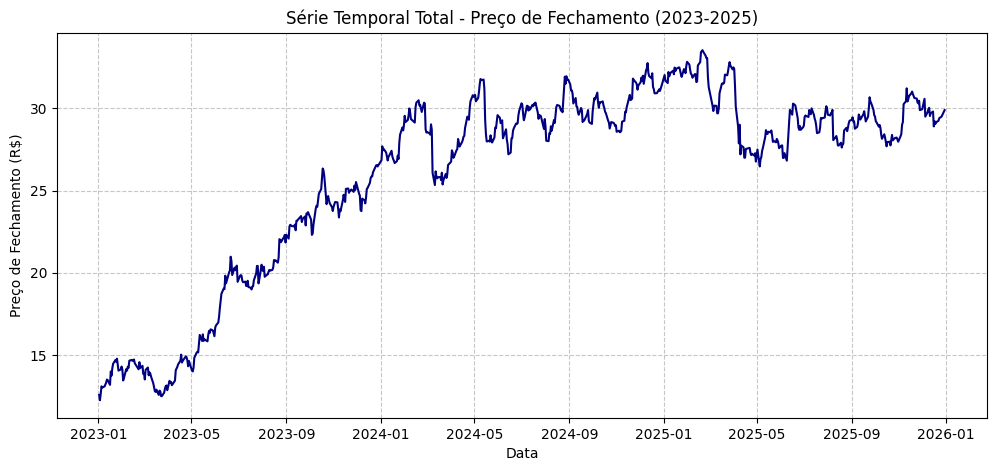

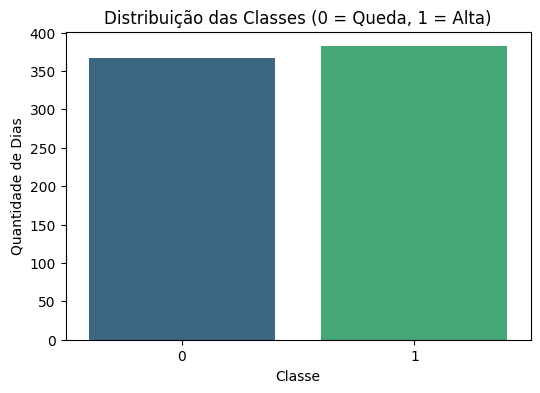

--------------------------------------------------
QUANTITATIVO DAS CLASSES NA BASE TOTAL:
Classe 1 (Dias de Alta): 51.00%
Classe 0 (Dias de Queda): 49.00%
--------------------------------------------------

QUANTIDADE DE ACERTOS E ERROS DE PREVISÃO (Teste 2025):
Verdadeiros Negativos (Acertou Queda): 101
Falsos Positivos (Errou, previu Alta mas foi Queda): 25
Falsos Negativos (Errou, previu Queda mas foi Alta): 59
Verdadeiros Positivos (Acertou Alta): 65
--------------------------------------------------

MEDIDAS DE AVALIAÇÃO:
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       126
           1       0.72      0.52      0.61       124

    accuracy                           0.66       250
   macro avg       0.68      0.66      0.66       250
weighted avg       0.68      0.66      0.66       250

Especificidade calculada: 0.8016
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gráfico de linha da série temporal total avaliada
plt.figure(figsize=(12, 5))
plt.plot(dados.index, dados['Close'], color='navy', linewidth=1.5)
plt.title('Série Temporal Total - Preço de Fechamento (2023-2025)')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Gráfico de barras e quantitativo em percentual das classes
plt.figure(figsize=(6, 4))
sns.countplot(x='Alvo', data=dados, palette='viridis', hue='Alvo', legend=False)
plt.title('Distribuição das Classes (0 = Queda, 1 = Alta)')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Dias')
plt.show()

percentuais = dados['Alvo'].value_counts(normalize=True) * 100
print("-" * 50)
print("QUANTITATIVO DAS CLASSES NA BASE TOTAL:")
print(f"Classe 1 (Dias de Alta): {percentuais[1]:.2f}%")
print(f"Classe 0 (Dias de Queda): {percentuais[0]:.2f}%")
print("-" * 50)

# 3. Quantidade de acertos e erros de previsão (Matriz de Confusão)
cm = confusion_matrix(y_teste, novas_previsoes)
print("\nQUANTIDADE DE ACERTOS E ERROS DE PREVISÃO (Teste 2025):")
print(f"Verdadeiros Negativos (Acertou Queda): {cm[0][0]}")
print(f"Falsos Positivos (Errou, previu Alta mas foi Queda): {cm[0][1]}")
print(f"Falsos Negativos (Errou, previu Queda mas foi Alta): {cm[1][0]}")
print(f"Verdadeiros Positivos (Acertou Alta): {cm[1][1]}")
print("-" * 50)

# 4. Medidas de avaliação
print("\nMEDIDAS DE AVALIAÇÃO:")
print(classification_report(y_teste, novas_previsoes))

# Calculando a especificidade manualmente (Verdadeiros Negativos / Total de Reais Negativos)
especificidade = cm[0][0] / (cm[0][0] + cm[0][1])
print(f"Especificidade calculada: {especificidade:.4f}")
print("-" * 50)

In [ ]:
# Criando um DataFrame focado no ano de teste (2025) para organizar os cálculos
df_financeiro = dados_teste.copy()

# Inserindo as previsões do nosso modelo melhorado (Etapa 6)
df_financeiro['Previsao'] = novas_previsoes

# Calculando o retorno percentual diário real da ação
# Fórmula: (Fechamento - Abertura) / Abertura
df_financeiro['Retorno_Diario'] = (df_financeiro['Close'] - df_financeiro['Open']) / df_financeiro['Open']

# Aplicando a estratégia do algoritmo:
# Multiplicamos o retorno diário pela previsão.
# Se Previsao == 1, pegamos o retorno do dia. Se Previsao == 0, o retorno é anulado (0).
df_financeiro['Retorno_Estrategia'] = df_financeiro['Retorno_Diario'] * df_financeiro['Previsao']

# Separando os dias de lucro e os dias de prejuízo da nossa estratégia
ganhos_percentuais = df_financeiro[df_financeiro['Retorno_Estrategia'] > 0]['Retorno_Estrategia'].sum() * 100
perdas_percentuais = df_financeiro[df_financeiro['Retorno_Estrategia'] < 0]['Retorno_Estrategia'].sum() * 100

# Calculando o retorno geral
retorno_geral = ganhos_percentuais + perdas_percentuais

print("-" * 50)
print("RESULTADOS FINANCEIROS DA ESTRATÉGIA NO PERÍODO DE TESTE (2025):")
print(f"Retorno financeiro dos ganhos: {ganhos_percentuais:.2f}%")
print(f"Retorno financeiro das perdas: {perdas_percentuais:.2f}%")
print(f"Retorno financeiro geral: {retorno_geral:.2f}%")
print("-" * 50)

--------------------------------------------------
RESULTADOS FINANCEIROS DA ESTRATÉGIA NO PERÍODO DE TESTE (2025):
Retorno financeiro dos ganhos: 65.41%
Retorno financeiro das perdas: -19.63%
Retorno financeiro geral: 45.78%
--------------------------------------------------


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Etapa 9: Criando o filtro para selecionar o período de dados de Treinamento por ano
filtro_ano = widgets.Dropdown(
    options=['Ambos (2023 e 2024)', 'Apenas 2023', 'Apenas 2024'],
    value='Ambos (2023 e 2024)',
    description='Ano Treino:',
    style={'description_width': 'initial'}
)

# Área onde o dashboard será renderizado
saida_dashboard = widgets.Output()

def atualizar_dashboard(ano_selecionado):
    with saida_dashboard:
        clear_output(wait=True)
        print(f"⏳ Recalculando modelo. Dados de Treinamento: {ano_selecionado}...")

        # Filtrando os dados de treinamento com base na seleção do usuário
        if ano_selecionado == 'Apenas 2023':
            treino_filtrado = dados.loc['2023-01-01':'2023-12-31']
        elif ano_selecionado == 'Apenas 2024':
            treino_filtrado = dados.loc['2024-01-01':'2024-12-31']
        else:
            treino_filtrado = dados.loc['2023-01-01':'2024-12-31']

        X_treino_dash = treino_filtrado[['Open', 'High', 'Low']]
        y_treino_dash = treino_filtrado['Alvo']

        # Reaplicando a normalização (Etapa 6)
        scaler_dash = StandardScaler()
        X_treino_norm_dash = scaler_dash.fit_transform(X_treino_dash)
        X_teste_norm_dash = scaler_dash.transform(X_teste_revisado) # 2025

        # Retreinando o modelo KNN
        modelo_dash = KNeighborsClassifier(n_neighbors=11)
        modelo_dash.fit(X_treino_norm_dash, y_treino_dash)

        # Gerando novas previsões
        previsoes_dash = modelo_dash.predict(X_teste_norm_dash)
        acc = accuracy_score(y_teste, previsoes_dash)

        # Etapa 8: Apresentação dos resultados (Dashboard)
        print(f"✅ Treinamento concluído! Acurácia no Teste (2025): {acc * 100:.2f}%\n")

        # Montando o layout dos gráficos
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

        # Gráfico 1: Série Temporal
        ax[0].plot(dados.index, dados['Close'], color='navy', alpha=0.8)
        ax[0].set_title('Série Temporal - Preço de Fechamento')
        ax[0].set_ylabel('Preço (R$)')
        ax[0].grid(True, linestyle='--', alpha=0.5)

        # Gráfico 2: Previsões do Modelo
        sns.countplot(x=previsoes_dash, ax=ax[1], palette='coolwarm')
        ax[1].set_title(f'Decisões do Robô em 2025 (Treino: {ano_selecionado})')
        ax[1].set_xticks([0, 1])
        ax[1].set_xticklabels(['Queda (Não Operar)', 'Alta (Comprar)'])
        ax[1].set_ylabel('Quantidade de Dias')

        plt.tight_layout()
        plt.show()

# Conectando o filtro à função de atualização
def ao_mudar_filtro(change):
    if change['type'] == 'change' and change['name'] == 'value':
        atualizar_dashboard(change['new'])

filtro_ano.observe(ao_mudar_filtro)

# Exibindo o Dashboard na tela
print("-" * 60)
print("DASHBOARD INTERATIVO - PREVISÃO DE AÇÕES B3")
print("-" * 60)
display(filtro_ano)
display(saida_dashboard)

# Chamada inicial para carregar o dashboard pela primeira vez
atualizar_dashboard(filtro_ano.value)

------------------------------------------------------------
DASHBOARD INTERATIVO - PREVISÃO DE AÇÕES B3
------------------------------------------------------------


Dropdown(description='Ano Treino:', options=('Ambos (2023 e 2024)', 'Apenas 2023', 'Apenas 2024'), style=Descr…

Output()